In [13]:
%%capture
from pathlib import Path

if Path.cwd().stem == "notebooks":
    %cd ..
    %load_ext autoreload
    %autoreload 2

In [38]:
import os
from pathlib import Path
from statistics import NormalDist

import altair as alt
import holoviews as hv
import hvplot.polars  # noqa  # noqa
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import tomllib
from dotenv import load_dotenv
from polars import col

from src.experiments.measurement.stimulus_generator import StimulusGenerator
from src.features.utils import to_describe
from src.log_config import configure_logging
from src.plots.plot_stimulus import (
    plot_stimulus,
)

load_dotenv()
FIGURE_DIR = Path(os.getenv("FIGURE_DIR"))


pl.Config.set_tbl_rows(12)  # for the 12 trials
hv.output(widget_location="bottom", size=130)
from src.data.database_manager import DatabaseManager
from src.features.scaling import scale_min_max
from src.plots.averages_over_stimulus_seeds import (
    average_over_stimulus_seeds,
    plot_single_stimulus_seed,
)

configure_logging(
    ignore_libs=("Comm", "bokeh", "tornado", "matplotlib"),
)

pl.Config.set_tbl_rows(12)  # for 12 seeds
hv.output(widget_location="bottom", size=150)

In [39]:
db = DatabaseManager()

In [40]:
with db:
    df = db.get_trials("Explore_Data", exclude_problematic=True)

df = df.rename({"rating": "pain_rating", "pupil": "pupil_diameter"})

df = scale_min_max(
    df,
    exclude_additional_columns=[
        # already normalized:
        "temperature",
        "pain_rating",
        "brow_furrow",
        "cheek_raise",
        "mouth_open",
        "upper_lip_raise",
        "nose_wrinkle",
    ],
)

In [41]:
def _calculate_z_score(confidence_level: float) -> float:
    """
    Calculate z-score for the given confidence level (e.g., 0.95 -> 1.96).
    """
    return NormalDist().inv_cdf((1 + confidence_level) / 2)

## Averaged trials over stimulus seeds with confidence intervals

In [42]:
signals = [
    "temperature",
    "pain_rating",
    "pupil_diameter",
    "eda_tonic",
    "eda_phasic",
    "heart_rate",
    "mouth_open",
]

confidence_level = 0.95
z_score = _calculate_z_score(confidence_level)

df = df.filter(col("stimulus_seed") == 133)

# Group by stimulus seed and normalized timestamp, then calculate mean, std, sem, ci
ci_values = (
    df.group_by(col("normalized_timestamp"), maintain_order=True)
    .agg(
        *[col(c).mean().alias(f"mean_{c}") for c in signals],
        *[col(c).std().alias(f"std_{c}") for c in signals],
        pl.len().alias("n"),
    )
    .sort("normalized_timestamp")
    .with_columns(
        *[(col(f"std_{c}") / col("n").sqrt()).alias(f"sem_{c}") for c in signals],
    )
    .with_columns(
        *[
            (col(f"mean_{c}") - z_score * col(f"sem_{c}")).alias(f"ci_lower_{c}")
            for c in signals
        ],
        *[
            (col(f"mean_{c}") + z_score * col(f"sem_{c}")).alias(f"ci_upper_{c}")
            for c in signals
        ],
    )
)

In [43]:
ci_values

normalized_timestamp,mean_temperature,mean_pain_rating,mean_pupil_diameter,mean_eda_tonic,mean_eda_phasic,mean_heart_rate,mean_mouth_open,std_temperature,std_pain_rating,std_pupil_diameter,std_eda_tonic,std_eda_phasic,std_heart_rate,std_mouth_open,n,sem_temperature,sem_pain_rating,sem_pupil_diameter,sem_eda_tonic,sem_eda_phasic,sem_heart_rate,sem_mouth_open,ci_lower_temperature,ci_lower_pain_rating,ci_lower_pupil_diameter,ci_lower_eda_tonic,ci_lower_eda_phasic,ci_lower_heart_rate,ci_lower_mouth_open,ci_upper_temperature,ci_upper_pain_rating,ci_upper_pupil_diameter,ci_upper_eda_tonic,ci_upper_eda_phasic,ci_upper_heart_rate,ci_upper_mouth_open
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.36777,0.817986,0.842322,0.425671,0.694208,0.063967,0.0,0.245469,0.168467,0.172791,0.294998,0.200352,0.150445,37,0.0,0.040355,0.027696,0.028407,0.048497,0.032938,0.024733,0.0,0.288676,0.763703,0.786646,0.330618,0.629651,0.015491,0.0,0.446864,0.872268,0.897999,0.520724,0.758764,0.112443
100.0,0.000184,0.380709,0.815849,0.843847,0.437848,0.708431,0.064199,0.000025,0.247465,0.178117,0.17077,0.28961,0.202023,0.151244,37,0.000004,0.040683,0.029282,0.028074,0.047612,0.033212,0.024864,0.000176,0.300972,0.758457,0.788822,0.344531,0.643336,0.015466,0.000192,0.460446,0.873242,0.898871,0.531165,0.773526,0.112933
200.0,0.000784,0.400342,0.81457,0.845285,0.455036,0.719241,0.064719,0.000087,0.245996,0.18692,0.168796,0.289537,0.204379,0.152755,37,0.000014,0.040441,0.030729,0.02775,0.0476,0.0336,0.025113,0.000756,0.321078,0.754342,0.790896,0.361742,0.653387,0.015499,0.000812,0.479606,0.874799,0.899673,0.548329,0.785095,0.113939
300.0,0.001871,0.419517,0.811261,0.846712,0.473843,0.727623,0.065076,0.000143,0.246142,0.196225,0.166743,0.290675,0.205764,0.153793,37,0.000023,0.040465,0.032259,0.027412,0.047787,0.033827,0.025283,0.001825,0.340207,0.748034,0.792985,0.380183,0.661322,0.015521,0.001917,0.498828,0.874488,0.900439,0.567504,0.793923,0.114631
400.0,0.003444,0.43083,0.805903,0.848108,0.497161,0.734009,0.065487,0.000197,0.248252,0.205165,0.164857,0.29521,0.206642,0.154679,37,0.000032,0.040812,0.033729,0.027102,0.048532,0.033972,0.025429,0.003381,0.350839,0.739796,0.794989,0.402039,0.667426,0.015647,0.003508,0.510821,0.872011,0.901228,0.592282,0.800592,0.115327
500.0,0.005515,0.443373,0.802354,0.849482,0.521489,0.737206,0.065674,0.00028,0.247539,0.212504,0.162865,0.298543,0.206851,0.155343,37,0.000046,0.040695,0.034935,0.026775,0.04908,0.034006,0.025538,0.005425,0.363612,0.733882,0.797004,0.425293,0.670555,0.01562,0.005605,0.523135,0.870826,0.90196,0.617684,0.803857,0.115728
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
179500.0,0.158899,0.484589,0.355889,0.185851,0.442689,0.529453,0.047111,0.000233,0.248002,0.160824,0.225302,0.145671,0.14707,0.103455,37,0.000038,0.040771,0.026439,0.037039,0.023948,0.024178,0.017008,0.158824,0.404679,0.304069,0.113255,0.395751,0.482065,0.013776,0.158974,0.564499,0.407709,0.258447,0.489626,0.576842,0.080445
179600.0,0.157452,0.471173,0.355701,0.18685,0.438051,0.529808,0.047258,0.000183,0.252247,0.160566,0.226321,0.146786,0.146094,0.103893,37,0.00003,0.041469,0.026397,0.037207,0.024131,0.024018,0.01708,0.157393,0.389895,0.303964,0.113926,0.390755,0.482735,0.013782,0.157511,0.552451,0.407438,0.259775,0.485348,0.576882,0.080734


In [44]:
signals = [
    "temperature",
    "pain_rating",
    "pupil_diameter",
    "eda_tonic",
    "eda_phasic",
    "heart_rate",
    "mouth_open",
]

SIGNAL_LABELS = {
    "temperature": "Temperature",
    "pain_rating": "Pain rating",
    "pupil_diameter": "Pupil diameter",
    "eda_tonic": "Tonic EDA",
    "eda_phasic": "Phasic EDA",
    "heart_rate": "Heart rate",
    "mouth_open": "Mouth open",
}

SIGNAL_COLORS = [
    "#17396b",  # Temperature - dark navy
    "#d45f3c",  # Pain Rating - orange-red
    "#e8a020",  # Pupil Diameter - golden yellow
    "#5a7a2e",  # Tonic EDA - olive green
    "#3a9e5f",  # Phasic EDA - medium green
    "#3ab8b8",  # Heart Rate - teal
    "#7b4fa0",  # Mouth Open - purple
]

src = ci_values  # no /1000 conversion

layers = []
for sig, color in zip(signals, SIGNAL_COLORS):
    label = SIGNAL_LABELS[sig]
    base = alt.Chart(src).transform_calculate(label=f"'{label}'")

    line = base.mark_line(color=color).encode(
        x=alt.X("normalized_timestamp:Q", title="Time (ms)"),
        y=alt.Y(f"mean_{sig}:Q", title="Normalized value"),
        tooltip=[
            alt.Tooltip("normalized_timestamp:Q", title="Time (ms)"),
            alt.Tooltip(f"mean_{sig}:Q", title=label, format=".2f"),
        ],
    )

    band = base.mark_area(opacity=0.2, color=color).encode(
        x=alt.X("normalized_timestamp:Q"),
        y=alt.Y(f"ci_lower_{sig}:Q"),
        y2=alt.Y2(f"ci_upper_{sig}:Q"),
    )

    layers.append(line + band)

legend_data = (
    alt.Chart(
        alt.Data(
            values=[
                {"signal": lbl, "color": c}
                for lbl, c in zip(SIGNAL_LABELS.values(), SIGNAL_COLORS)
            ]
        )
    )
    .mark_line()
    .encode(
        color=alt.Color(
            "signal:N",
            scale=alt.Scale(domain=list(SIGNAL_LABELS.values()), range=SIGNAL_COLORS),
            legend=alt.Legend(
                title="",
                orient="right",
                symbolType="stroke",  # ← line instead of square
                symbolStrokeWidth=3,  # ← thicker line
                symbolSize=400,  # ← longer line
                labelFontSize=12,
                rowPadding=4,  # ← spacing between rows
            ),
        )
    )
)
fig = (
    alt.layer(*layers, legend_data)
    .properties(
        width=800,
        height=400,
    )
    .configure_axis(
        grid=False,
        gridColor="#dddddd",
        gridOpacity=0.8,
        titleFontWeight="normal",
        labelFontWeight="normal",
    )
    .configure_view(stroke=None, fill="white")
)

# fig.save(FIGURE_DIR / "average_ratings_around_major_decreases_all_signals.svg")
fig

alt.LayerChart(...)

In [45]:
def load_configuration(file_path: str) -> dict:
    """Load configuration from a TOML file."""
    file_path = Path(file_path)
    with open(file_path, "rb") as file:
        return tomllib.load(file)


config = load_configuration("src/experiments/measurement/measurement_config.toml")[
    "stimulus"
]


In [56]:
config = {
    "seeds": config["seeds"],
    "sample_rate": config["sample_rate"],
    "half_cycle_num": config["half_cycle_num"],
    "period_range": config["period_range"],
    "amplitude_range": config["amplitude_range"],
    "inflection_point_range": config["inflection_point_range"],
    "shorten_expected_duration": config["shorten_expected_duration"],
    "major_decreasing_half_cycle_num": config["major_decreasing_half_cycle_num"],
    "major_decreasing_half_cycle_period": config["major_decreasing_half_cycle_period"],
    "major_decreasing_half_cycle_amplitude": config[
        "major_decreasing_half_cycle_amplitude"
    ],
    "major_decreasing_half_cycle_min_y_intercept": config[
        "major_decreasing_half_cycle_min_y_intercept"
    ],
    "plateau_num": config["plateau_num"],
    "plateau_duration": config["plateau_duration"],
    "plateau_percentile_range": config["plateau_percentile_range"],
    "prolonged_minima_num": config["prolonged_minima_num"],
    "prolonged_minima_duration": config["prolonged_minima_duration"],
}
assert len(config["seeds"]) == len(set(config["seeds"])), "Seeds must be unique"
assert len(config["seeds"]) == 12, "There must be 12 seeds"

dummy_participant = {
    "temperature_baseline": 44.0,
    "temperature_range": 4,  # VAS 0 - VAS 70
}


dummy_config = {
    "seeds": [1, 2, 3],
    "half_cycle_num": 2,
    "period_range": [2, 2],
    "major_decreasing_half_cycle_num": 0,
    "shorten_expected_duration": 0,
    "amplitude_range": [0.9, 1.0],
    "plateau_num": 0,
    "prolonged_minima_num": 0,
}

# Plot one random seed
config.update(dummy_participant)
seed = np.random.randint(0, 1000)
stimulus = StimulusGenerator(config, debug=0, seed=467)


In [57]:
stimuli = pl.concat(
    [
        pl.DataFrame(
            {
                "y": StimulusGenerator(config, seed).y,
                "time": np.arange(len(StimulusGenerator(config, seed).y)),
                "seed": np.array([seed] * len(StimulusGenerator(config, seed).y)),
            }
        )
        for seed in config["seeds"]
    ]
)


In [64]:
dummy_participant = {
    "temperature_baseline": 45.0,
    "temperature_range": 4,  # VAS 0 - VAS 70
}
config.update(dummy_participant)


stimulus = StimulusGenerator(config, seed=133)

In [65]:
import altair as alt
import numpy as np
import pandas as pd


def plot_stimulus_with_labels_altair_single_panel(
    stimulus,
    filename=None,
    width=1150,
    height=430,
):
    colors = {
        "decreasing_intervals": "#d32f2f",
        "major_decreasing_intervals": "#ff6f60",
        "increasing_intervals": "#388e3c",
        "strictly_increasing_intervals": "#66bb6a",
        "strictly_increasing_intervals_without_plateaus": "#a5d6a7",
        "plateau_intervals": "#1976d2",
        "prolonged_minima_intervals": "#90caf9",
    }

    label_names = {
        "decreasing_intervals": "Decreasing",
        "major_decreasing_intervals": "Major decreasing",
        "increasing_intervals": "Increasing",
        "strictly_increasing_intervals": "Strictly increasing",
        "strictly_increasing_intervals_without_plateaus": "Strictly increasing\n(no plateaus)",
        "plateau_intervals": "Plateau",
        "prolonged_minima_intervals": "Prolonged minima",
    }

    # Keep an explicit order so lane positions and axis labels are stable.
    order = [
        "decreasing_intervals",
        "major_decreasing_intervals",
        "increasing_intervals",
        "strictly_increasing_intervals",
        "strictly_increasing_intervals_without_plateaus",
        "plateau_intervals",
        "prolonged_minima_intervals",
    ]

    labels = dict(stimulus.labels)
    labels["strictly_increasing_intervals"] = [
        stimulus._convert_interval(interval)
        for interval in stimulus.strictly_increasing_intervals_complete_idx
    ]
    labels = {k: labels.get(k, []) for k in order}

    temp = np.asarray(stimulus.y, dtype=float)
    sample_rate = float(stimulus.sample_rate)
    time_s = np.arange(temp.size, dtype=float) / sample_rate
    duration = temp.size / sample_rate

    interval_rows = []
    for interval_type in order:
        interval_label = label_names[interval_type]
        for start_ms, end_ms in labels[interval_type]:
            # Snap boundaries to sample indices so bars align with the plotted signal grid.
            start_idx = int(np.round((start_ms / 1000.0) * sample_rate))
            end_idx = int(np.round((end_ms / 1000.0) * sample_rate))

            start_idx = int(np.clip(start_idx, 0, temp.size))
            end_idx = int(np.clip(end_idx, 0, temp.size))
            if end_idx <= start_idx:
                end_idx = min(start_idx + 1, temp.size)
            if end_idx <= start_idx:
                continue

            interval_rows.append(
                {
                    "interval_type": interval_type,
                    "interval_label": interval_label,
                    "start_s": start_idx / sample_rate,
                    "end_s": end_idx / sample_rate,
                }
            )

    interval_df = pd.DataFrame(
        interval_rows,
        columns=["interval_type", "interval_label", "start_s", "end_s"],
    )
    temp_df = pd.DataFrame({"time_s": time_s, "temperature": temp})

    interval_order = [label_names[k] for k in order]
    interval_axis_df = pd.DataFrame(
        {
            "interval_label": interval_order,
        }
    )

    tick_step = 10 if duration <= 120 else 20
    x_ticks = np.arange(0, int(np.floor(duration)) + 1, tick_step).tolist()
    if not x_ticks:
        x_ticks = [0]
    if x_ticks[-1] != int(np.floor(duration)):
        x_ticks.append(int(np.floor(duration)))

    t_min = float(temp.min())
    t_max = float(temp.max())
    t_span = max(t_max - t_min, 0.25)

    x_scale = alt.Scale(domain=[0, duration])
    x_axis = alt.Axis(values=x_ticks, title="Time (s)")
    y_temp_scale = alt.Scale(domain=[t_min - 0.05 * t_span, t_max + 0.05 * t_span])

    interval_y = alt.Y(
        "interval_label:N",
        sort=interval_order,
        scale=alt.Scale(domain=interval_order),
        axis=alt.Axis(
            orient="right",
            title="Interval Type",
            titleAngle=90,
            titlePadding=16,
            ticks=True,
            tickSize=6,
            labelAngle=30,
            labelAlign="left",
            labelBaseline="middle",
        ),
    )

    bands = (
        alt.Chart(interval_df)
        .mark_bar(opacity=0.35, size=26)
        .encode(
            x=alt.X("start_s:Q", scale=x_scale, axis=x_axis),
            x2="end_s:Q",
            y=interval_y,
            color=alt.Color(
                "interval_type:N",
                scale=alt.Scale(
                    domain=order,
                    range=[colors[k] for k in order],
                ),
                legend=None,
            ),
            tooltip=[
                alt.Tooltip("interval_label:N", title="Type"),
                alt.Tooltip("start_s:Q", title="Start (s)", format=".2f"),
                alt.Tooltip("end_s:Q", title="End (s)", format=".2f"),
            ],
        )
    )

    # Invisible points keep all interval labels on the right axis even if one type has no spans.
    interval_axis = (
        alt.Chart(interval_axis_df)
        .mark_point(opacity=0)
        .encode(
            x=alt.value(0),
            y=interval_y,
        )
    )

    line = (
        alt.Chart(temp_df)
        .mark_line(color="#000080", strokeWidth=4)
        .encode(
            x=alt.X("time_s:Q", scale=x_scale, axis=x_axis),
            y=alt.Y(
                "temperature:Q",
                title="Temperature (deg C)",
                scale=y_temp_scale,
                axis=alt.Axis(tickMinStep=0.5),
            ),
            tooltip=[
                alt.Tooltip("time_s:Q", title="Time (s)", format=".2f"),
                alt.Tooltip("temperature:Q", title="Temperature (deg C)", format=".3f"),
            ],
        )
    )

    chart = (
        alt.layer(bands, interval_axis, line)
        .resolve_scale(y="independent")
        .properties(width=width, height=height)
        .configure_axis(
            grid=False,
            gridColor="#d9d9d9",
            gridDash=[4, 4],
            gridOpacity=0.55,
            labelFontSize=12,
            titleFontSize=14,
        )
        .configure_view(stroke="#b7b7b7")
    )

    if filename:
        chart.save(filename)

    return chart

In [66]:
plot_stimulus_with_labels_altair_single_panel(stimulus)

alt.LayerChart(...)

In [58]:
def load_configuration(file_path: str) -> dict:
    """Load configuration from a TOML file."""
    file_path = Path(file_path)
    with open(file_path, "rb") as file:
        return tomllib.load(file)


config = load_configuration("src/experiments/measurement/measurement_config.toml")[
    "stimulus"
]


In [60]:
stimuli = pl.concat(
    [
        pl.DataFrame(
            {
                "y": StimulusGenerator(config, seed).y,
                "time": np.arange(len(StimulusGenerator(config, seed).y)),
                "seed": np.array([seed] * len(StimulusGenerator(config, seed).y)),
            }
        )
        for seed in config["seeds"]
    ]
)
stimuli.group_by("seed", maintain_order=True).agg(to_describe("y"))

seed,y_count,y_null_count,y_mean,y_std,y_min,y_25%,y_50%,y_75%,y_max
i64,u32,u32,f64,f64,f64,f64,f64,f64,f64
133,360,0,46.919194,0.429477,46.25,46.617481,46.795802,47.240074,47.746504
243,360,0,46.938387,0.4239,46.25,46.625412,46.943262,47.277994,47.738635
265,360,0,46.947067,0.443919,46.25,46.589575,46.944351,47.290572,47.744373
396,360,0,46.983353,0.4154,46.25,46.726121,46.955086,47.309396,47.731835
467,360,0,46.962872,0.42506,46.25,46.680212,46.935986,47.293592,47.737302
658,360,0,46.962511,0.417892,46.25,46.613611,46.966656,47.26712,47.704574
681,360,0,46.92275,0.414812,46.25,46.610843,46.88708,47.245023,47.739538
743,360,0,46.967253,0.415066,46.25,46.70841,46.937123,47.290805,47.738548
806,360,0,46.910445,0.446949,46.25,46.528838,46.909143,47.248535,47.749272


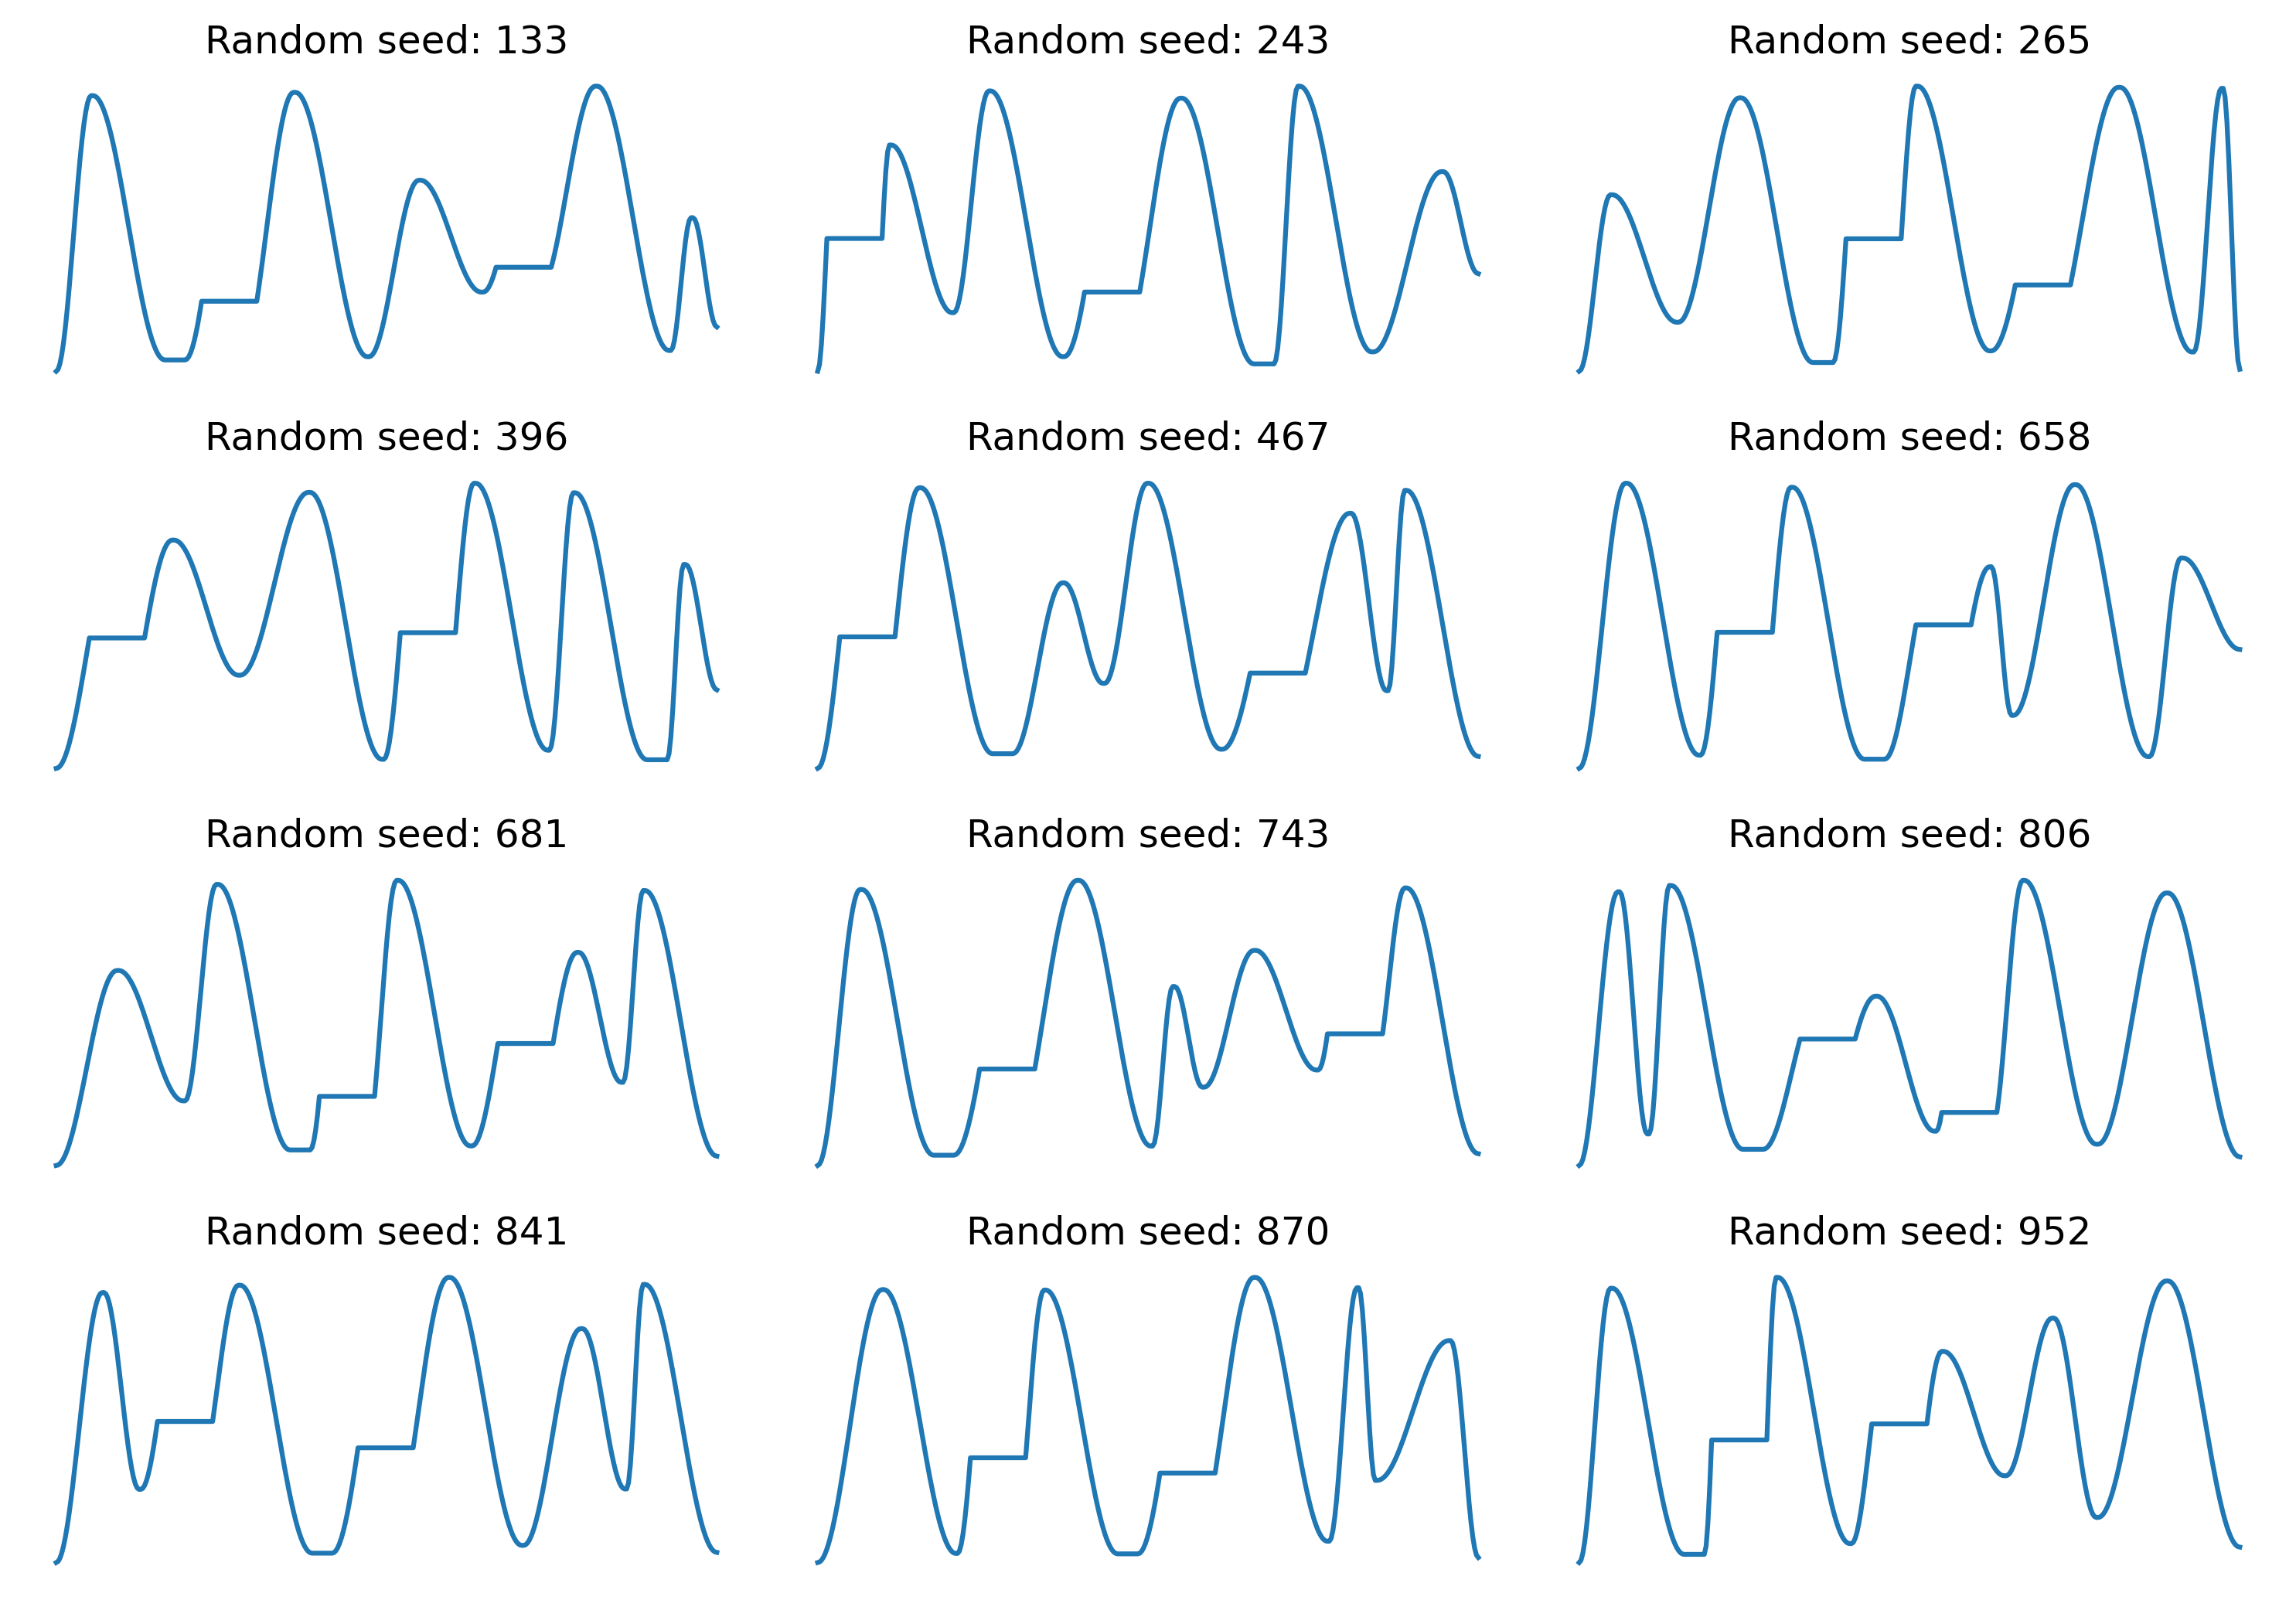

In [61]:
rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.flatten()

grouped = stimuli.group_by("seed", maintain_order=True).agg(col("time"), col("y"))
for i, row in enumerate(grouped.to_dicts()):
    ax = axes[i]
    ax.plot(row["time"], row["y"])
    ax.set_title(f"Random seed: {row['seed']}")
    ax.axis(False)

plt.tight_layout()
plt.show()


In [62]:
# fig.savefig(FIGURE_DIR / "stimulus_seeds.png", dpi=300)

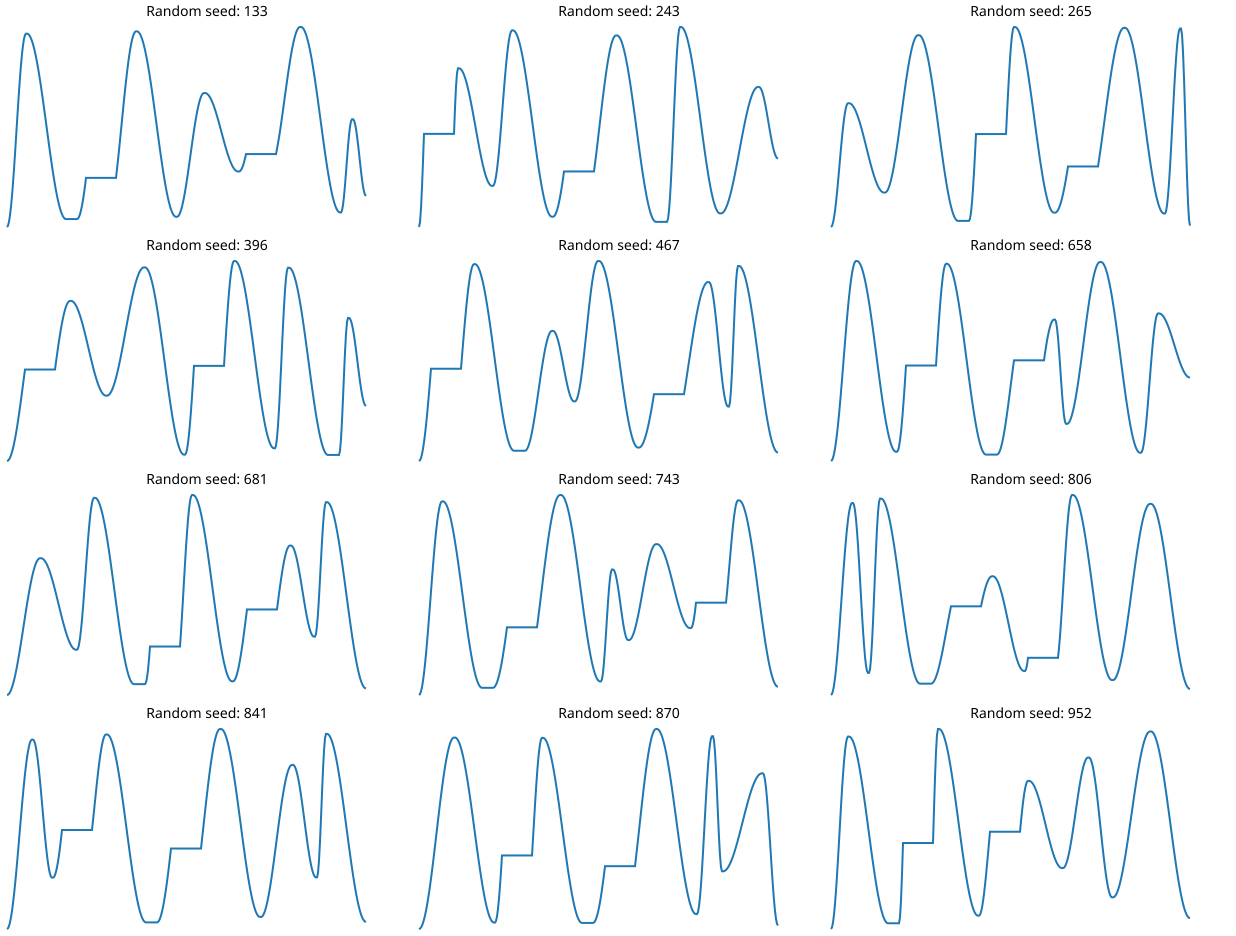

In [71]:
import altair as alt

alt.renderers.enable("svg")  # vector rendering, much sharper text


def plot_stimulus_seed_grid_altair(
    stimuli: pl.DataFrame,
    columns: int = 3,
    width: int = 220,
    height: int = 130,
) -> alt.Chart:
    """Plot each stimulus seed as a faceted Altair line chart using Polars data."""
    required_columns = {"seed", "time", "y"}
    missing_columns = required_columns.difference(stimuli.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"Missing required columns: {missing}")

    chart_data = (
        stimuli.select("seed", "time", "y")
        .sort(["seed", "time"])
        .with_columns(
            pl.concat_str(
                [pl.lit("Random seed: "), pl.col("seed").cast(pl.String)]
            ).alias("seed_label")
        )
    )

    base = (
        alt.Chart(chart_data)
        .mark_line(color="#1f77b4", strokeWidth=2)
        .encode(
            x=alt.X(
                "time:Q",
                axis=None,
                scale=alt.Scale(zero=False),
            ),
            y=alt.Y(
                "y:Q",
                axis=None,
                scale=alt.Scale(zero=False, nice=False),
            ),
            tooltip=[
                alt.Tooltip("seed:Q", title="Seed"),
                alt.Tooltip("time:Q", title="Time", format=".0f"),
                alt.Tooltip("y:Q", title="Temperature", format=".3f"),
            ],
        )
        .properties(width=width, height=height)
    )

    return (
        base.facet(
            facet=alt.Facet("seed_label:N", title=None),
            columns=columns,
        )
        .resolve_scale(x="shared", y="independent")
        .configure_view(stroke=None)
        .configure_facet(spacing=10)
        .configure_header(
            labelFontSize=14,
            labelFontWeight="normal",
            labelOrient="top",
            labelPadding=6,
            title=None,
        )
    )


plot_stimulus_seed_grid_altair(stimuli)
chart = plot_stimulus_seed_grid_altair(stimuli, columns=3, width=400, height=200)
chart


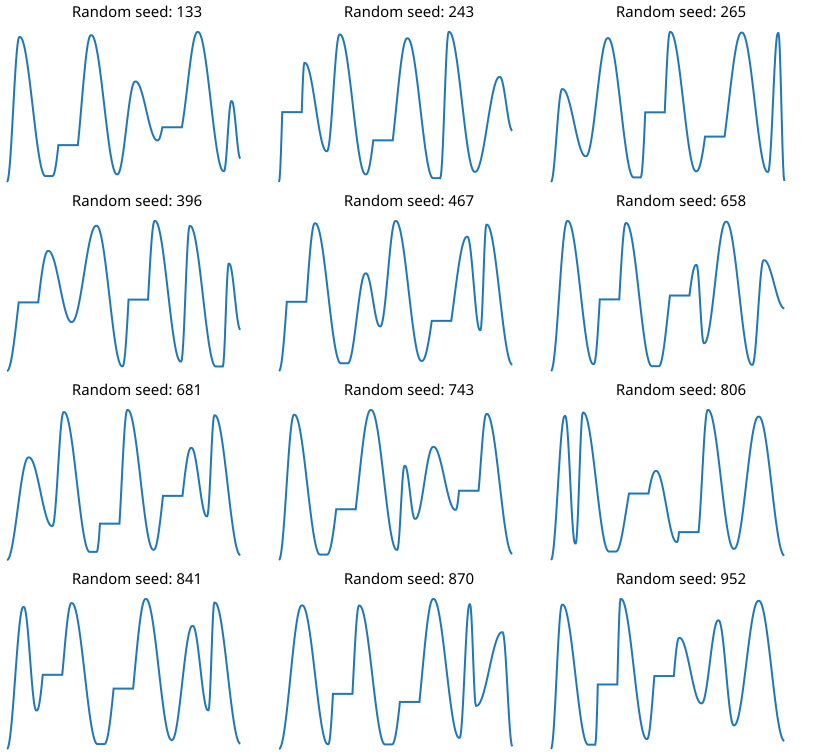

In [72]:
import altair as alt

alt.renderers.enable("svg")  # vector rendering, much sharper text


def plot_stimulus_seed_grid_altair(
    stimuli: pl.DataFrame,
    columns: int = 3,
    width: int = 220,
    height: int = 130,
) -> alt.Chart:
    """Plot each stimulus seed as a faceted Altair line chart using Polars data."""
    required_columns = {"seed", "time", "y"}
    missing_columns = required_columns.difference(stimuli.columns)
    if missing_columns:
        missing = ", ".join(sorted(missing_columns))
        raise ValueError(f"Missing required columns: {missing}")

    chart_data = (
        stimuli.select("seed", "time", "y")
        .sort(["seed", "time"])
        .with_columns(
            pl.concat_str(
                [pl.lit("Random seed: "), pl.col("seed").cast(pl.String)]
            ).alias("seed_label")
        )
    )

    base = (
        alt.Chart(chart_data)
        .mark_line(color="#1f77b4", strokeWidth=2)
        .encode(
            x=alt.X(
                "time:Q",
                axis=None,
                scale=alt.Scale(zero=False),
            ),
            y=alt.Y(
                "y:Q",
                axis=None,
                scale=alt.Scale(zero=False, nice=False),
            ),
            tooltip=[
                alt.Tooltip("seed:Q", title="Seed"),
                alt.Tooltip("time:Q", title="Time", format=".0f"),
                alt.Tooltip("y:Q", title="Temperature", format=".3f"),
            ],
        )
        .properties(width=width, height=height)
    )

    return (
        base.facet(
            facet=alt.Facet("seed_label:N", title=None),
            columns=columns,
        )
        .resolve_scale(x="shared", y="independent")
        .configure_view(stroke=None)
        .configure_facet(spacing=10)
        .configure_header(
            labelFontSize=14,
            labelFontWeight="normal",
            labelOrient="top",
            labelPadding=6,
            title=None,
        )
    )


plot_stimulus_seed_grid_altair(stimuli)
chart = plot_stimulus_seed_grid_altair(stimuli, columns=3, width=260, height=150)
chart = chart.configure_header(labelFontSize=15)
chart